# Pairwise Conformer RMSD: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 7 of the nvMolKit acceleration series.**

The all-pairs RMSD matrix between a molecule's conformers is the standard input to conformer clustering
(e.g. Butina, Tutorial 9). For each molecule it is **O(nConfs²)** pairwise alignments, and across a library of
molecules it is a large independent batch — a good fit for the GPU.

This notebook compares:

- **RDKit (CPU)** — `AllChem.GetConformerRMSMatrix(mol)` per molecule.
- **nvMolKit (GPU)** — `nvmolkit.conformerRmsd.GetConformerRMSMatrixBatch(mols)`, all molecules in one launch.

**Alignment semantics (read this):** by default (`prealigned=False`) RDKit aligns every conformer to the
*first* conformer and then measures RMSD, while nvMolKit performs an *optimal per-pair* Kabsch alignment. The two
therefore agree closely but not bit-for-bit (nvMolKit's per-pair value is arguably the more accurate minimal
RMSD). When both are given the **same pre-aligned conformers** with `prealigned=True`, they match exactly — we
use that for the correctness check, then benchmark the realistic default mode.

> RDKit's RMSD matrix has no native threaded path, so the `rdkit_16thread` column is a 16-way **multi-process**
> baseline (consistent with Tutorial 6). Strip hydrogens for heavy-atom RMSD. Run from `examples/tutorials/`.


## 1. Setup and GPU check

In [1]:
import copy
import multiprocessing
import time
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, AddHs, RemoveHs, AllChem
from rdkit.Chem.rdMolAlign import AlignMolConformers
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.conformerRmsd import GetConformerRMSMatrixBatch

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
N_CPU_THREADS = 16   # consistent with tutorials 1-5; here a 16-process CPU baseline
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 30                   # O(nConfs^2) pairs => 435 pairs per molecule
RANDOM_SEED = 42
SIZES = [10, 25, 50]                 # number of molecules
MIN_HEAVY, MAX_HEAVY = 15, 30
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, pairs/mol={CONFS_PER_MOL*(CONFS_PER_MOL-1)//2}, sizes={SIZES}")

confs/mol=30, pairs/mol=435, sizes=[10, 25, 50]


## 3. Load molecules, embed conformers, strip hydrogens (once)

We embed `CONFS_PER_MOL` conformers, then `RemoveHs` so RMSD is computed over heavy atoms (both backends use the
same atoms). Only molecules that embedded the full conformer set are kept.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=10000).iloc[:, 0].tolist()
params = ETKDGv3(); params.randomSeed = RANDOM_SEED

mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None or not (MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY):
        continue
    mh = AddHs(m)
    EmbedMultipleConfs(mh, numConfs=CONFS_PER_MOL, params=params)
    if mh.GetNumConformers() == CONFS_PER_MOL:
        mols_all.append(RemoveHs(mh))           # heavy-atom RMSD
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules x {CONFS_PER_MOL} conformers (heavy atoms); sweep sizes = {SIZES}")

Prepared 50 molecules x 30 conformers (heavy atoms); sweep sizes = [10, 25, 50]


## 4. Define the backends

RDKit's `GetConformerRMSMatrix` aligns conformers in place, so we always pass fresh copies. The flat lower-
triangular vectors are concatenated across molecules for comparison. The 16-way baseline spreads the per-molecule
loop across worker processes.

In [4]:
def fresh_copies(mols):
    return [copy.deepcopy(m) for m in mols]


def _rdkit_rms_one(mol):
    # Default mode (prealigned=False): align-to-first then measure.
    return list(AllChem.GetConformerRMSMatrix(mol))


def rdkit_rms(mols):                              # 1 thread (serial)
    return np.concatenate([np.array(_rdkit_rms_one(m)) for m in mols])


def rdkit_rms_parallel(mols, workers=N_CPU_THREADS):   # 16-way multi-process
    ctx = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as ex:
        results = list(ex.map(_rdkit_rms_one, mols))
    return np.concatenate([np.array(r) for r in results])


def nvmolkit_rms(mols, prealigned=False):
    res = GetConformerRMSMatrixBatch(mols, prealigned=prealigned)
    out = [np.asarray(r.numpy()) for r in res]
    torch.cuda.synchronize()
    return np.concatenate(out)

## 5. Correctness check

**Exact check** — give both backends the *same pre-aligned* conformers and `prealigned=True`; the RMSD math
must match bit-for-bit. **Default-mode agreement** — also report how close the realistic default mode is (it
differs slightly because RDKit aligns to the first conformer while nvMolKit aligns each pair optimally).

In [5]:
sample = mols_all[:max(SIZES)]

# Exact: shared pre-alignment, then prealigned=True on both
prealigned_mols = fresh_copies(sample)
for m in prealigned_mols:
    AlignMolConformers(m)
rd_exact = np.concatenate([np.array(AllChem.GetConformerRMSMatrix(copy.deepcopy(m), prealigned=True))
                           for m in prealigned_mols])
nv_exact = nvmolkit_rms(fresh_copies(prealigned_mols), prealigned=True)
print("EXACT (prealigned=True on shared aligned conformers):")
print(f"  pairs compared : {len(rd_exact)}")
print(f"  max |Delta|    : {np.abs(rd_exact - nv_exact).max():.2e} A")
print(f"  correlation    : {np.corrcoef(rd_exact, nv_exact)[0, 1]:.6f}")

# Default-mode agreement (realistic path)
rd_def = rdkit_rms(fresh_copies(sample))
nv_def = nvmolkit_rms(fresh_copies(sample), prealigned=False)
print("\nDEFAULT mode (prealigned=False; different alignment conventions):")
print(f"  mean |Delta|   : {np.abs(rd_def - nv_def).mean():.4f} A")
print(f"  correlation    : {np.corrcoef(rd_def, nv_def)[0, 1]:.4f}")
print(f"  mean(RDKit - nvMolKit) = {np.mean(rd_def - nv_def):+.4f} A  (RDKit >= optimal per-pair RMSD)")

EXACT (prealigned=True on shared aligned conformers):
  pairs compared : 21750
  max |Delta|    : 8.88e-16 A
  correlation    : 1.000000



DEFAULT mode (prealigned=False; different alignment conventions):
  mean |Delta|   : 0.0950 A
  correlation    : 0.9617
  mean(RDKit - nvMolKit) = +0.0950 A  (RDKit >= optimal per-pair RMSD)


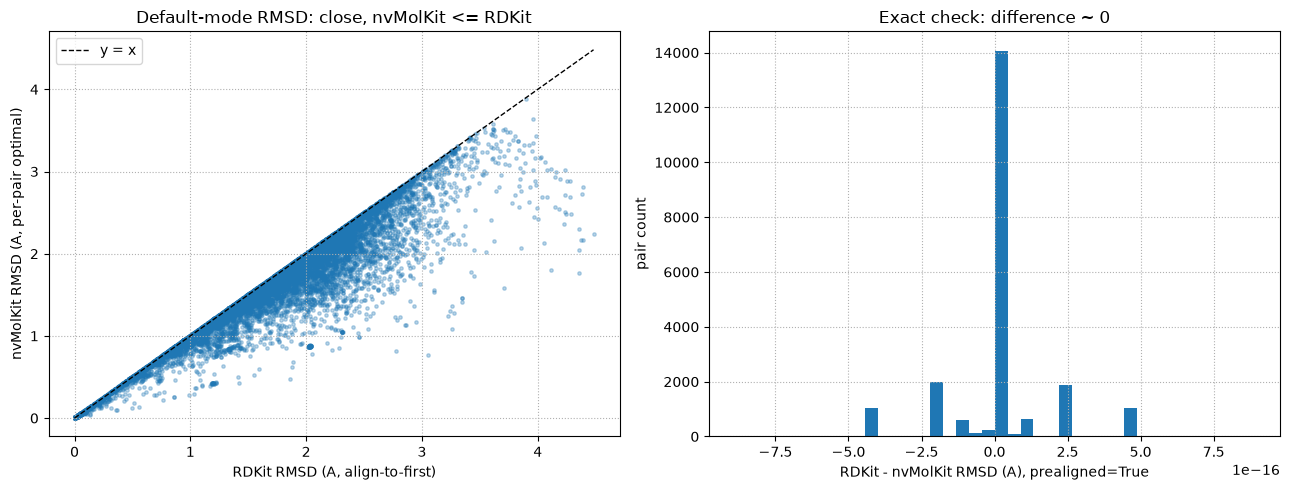

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lo, hi = 0, max(rd_def.max(), nv_def.max())
ax1.scatter(rd_def, nv_def, s=6, alpha=0.3)
ax1.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax1.set_xlabel("RDKit RMSD (A, align-to-first)")
ax1.set_ylabel("nvMolKit RMSD (A, per-pair optimal)")
ax1.set_title("Default-mode RMSD: close, nvMolKit <= RDKit")
ax1.legend(); ax1.grid(True, ls=":")

ax2.hist(rd_exact - nv_exact, bins=40)
ax2.set_xlabel("RDKit - nvMolKit RMSD (A), prealigned=True")
ax2.set_ylabel("pair count")
ax2.set_title("Exact check: difference ~ 0")
ax2.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 6. Warm up the GPU

In [7]:
_ = nvmolkit_rms(fresh_copies(mols_all[:5]))
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

Realistic default mode (`prealigned=False`, includes alignment). RDKit 1-thread (serial) and 16-thread
(16 processes) vs nvMolKit GPU (one batched launch for all molecules).

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(rdkit_rms, fresh_copies(base))
    t_rdN = timed(rdkit_rms_parallel, fresh_copies(base))
    t_gpu = timed(nvmolkit_rms, fresh_copies(base))
    total_pairs = n * CONFS_PER_MOL * (CONFS_PER_MOL - 1) // 2
    rows.append({
        "n_mols": n,
        "total_pairs": total_pairs,
        "rdkit_1thread_s": t_rd1,
        "rdkit_16thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_pairs_per_s": total_pairs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        "speedup_vs_16thread": t_rdN / t_gpu,
    })
    print(f"n={n:4d} | pairs={total_pairs:7d} | RDKit-1t {t_rd1:7.3f}s | "
          f"RDKit-16t {t_rdN:6.3f}s | nvMolKit {t_gpu:6.4f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  10 | pairs=   4350 | RDKit-1t   0.121s | RDKit-16t  0.166s | nvMolKit 0.0023s | speedup   51.8x /  70.9x


n=  25 | pairs=  10875 | RDKit-1t   0.297s | RDKit-16t  0.176s | nvMolKit 0.0030s | speedup  100.0x /  59.1x


n=  50 | pairs=  21750 | RDKit-1t   0.594s | RDKit-16t  0.258s | nvMolKit 0.0040s | speedup  147.9x /  64.2x


,n_mols,total_pairs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_pairs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,10,4350,0.121303,0.165912,0.002341,1.858448e+06,51.824017,70.882512
1,25,10875,0.297238,0.175686,0.002971,3.660114e+06,100.039015,59.129122
2,50,21750,0.593711,0.257920,0.004015,5.416551e+06,147.855897,64.231539


## 8. Plot: runtime and speedup vs number of molecules

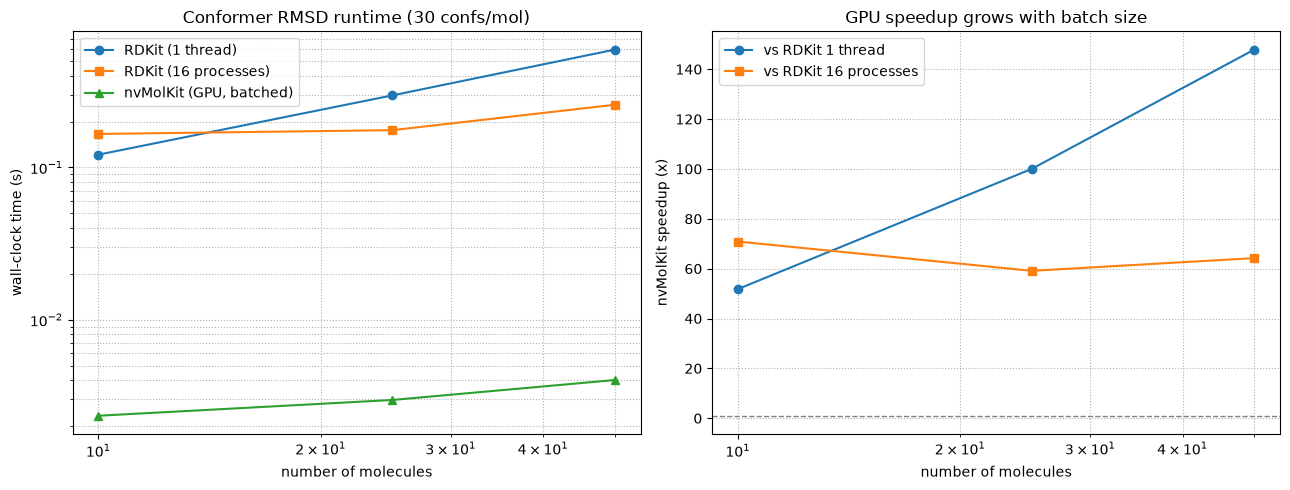

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df["rdkit_16thread_s"], "s-", label="RDKit (16 processes)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU, batched)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"Conformer RMSD runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df["speedup_vs_16thread"], "s-", label="vs RDKit 16 processes")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Exact when controlled.** Given the same pre-aligned conformers, nvMolKit's RMSD values are bit-identical to
  RDKit. In the default mode they agree closely; the small gap is an alignment convention (RDKit aligns to the
  first conformer, nvMolKit aligns each pair optimally, so nvMolKit's value is <= RDKit's).
- **Batched and fast.** `GetConformerRMSMatrixBatch` computes every molecule's matrix in a single launch, giving
  a large speedup that grows with the number of molecules.
- **Feeds clustering.** The lower-triangular output plugs straight into `nvmolkit.clustering.butina`
  (Tutorial 9) and the per-molecule `GetConformerRMSMatrix` exists for the single-molecule case.
- **Heavy atoms.** Strip hydrogens first for heavy-atom RMSD; use `prealigned=True` to skip Kabsch if your
  conformers are already aligned.

**Next:** Tutorial 8 covers Torsion Fingerprint Deviation (TFD).